Run the installation cell once, then choose **Run all**. All data is synthetic. The saved outputs were executed against the local package.

[Documentation](https://datakim.github.io/lendrisk/)


In [ ]:
%pip install -q "git+https://github.com/datakim/lendrisk.git@v0.1.0a2" matplotlib

# Follow a revenue-financing contract from funding to repayment

You will separate historical cash flow from a future scenario, define a
revenue-share contract, inspect its daily schedule, and compare sales shocks.
The data is synthetic. Amounts use one currency throughout; the demo charts use
dollar formatting.

## 1. Separate history and future


In [1]:
from lendrisk import cashflow_features, make_merchant_cashflows

data = make_merchant_cashflows(days=540, seed=42)
history = data.iloc[:180]
future = data.iloc[180:]
features = cashflow_features(history, as_of=history["date"].max())
print(features[["90d_revenue_mean", "90d_revenue_cv", "90d_operating_margin"]].round(3))

90d_revenue_mean        1052.330
90d_revenue_cv             0.235
90d_operating_margin       0.369
Name: cashflow_features, dtype: float64


`history` describes what was observed by the underwriting date. `future` is a
supplied 360-day path. It is separate from the feature calculation to avoid using
future sales as historical evidence. For real applications, provide your own
future assumptions or forecasting model.

`revenue_cv` is standard deviation divided by mean revenue: more relative
day-to-day variation gives a higher value. `operating_margin` is operating cash
divided by revenue. [See all feature definitions](https://github.com/datakim/lendrisk/blob/main/docs/api.md#cash-flow-features).

## 2. Define the contract


In [2]:
from lendrisk import RevenueAdvance

advance = RevenueAdvance(principal=30_000, factor_rate=1.12, holdback_rate=0.10)
result = advance.simulate(future, opening_cash=5_000)
print(result.summary())
print(result.schedule[["date", "revenue", "payment", "remaining_balance", "cash_balance"]].head())

{'principal': 30000.0, 'target_repayment': 33600.0, 'total_paid': 33600.000000000015, 'remaining_balance': 0.0, 'repaid': True, 'payoff_date': Timestamp('2026-06-01 00:00:00'), 'payoff_days': 337, 'horizon_days': 360, 'recovery_ratio': 1.0000000000000004, 'effective_annual_return': 0.27097544468793067, 'return_status': 'calculated', 'minimum_cash_balance': 35363.27947135184, 'negative_cash_days': 0, 'total_minimum_topup': 0.0, 'milestones_observed': 0, 'milestones_breached': 0}
        date      revenue     payment  remaining_balance  cash_balance
0 2025-06-30  1176.999174  117.699917       33482.300083  35363.279471
1 2025-07-01   945.149951   94.514995       33387.785087  35578.175440
2 2025-07-02   831.491046   83.149105       33304.635983  35720.329710
3 2025-07-03  1123.942687  112.394269       33192.241714  36049.653029
4 2025-07-04   979.480115   97.948011       33094.293703  36286.520303


| Term | Meaning in this example |
| --- | --- |
| `principal=30_000` | Funds delivered the day before the future path starts |
| `factor_rate=1.12` | A fixed 33,600 total receivable, including a 3,600 fee |
| `holdback_rate=0.10` | 10% of each supplied day's eligible revenue |
| `opening_cash=5_000` | Merchant cash before the 30,000 funding inflow |

The last payment is capped at the remaining receivable. Once paid off, payments
stop and the schedule continues through the full path. A repayment factor
does not specify an annual interest rate; dated returns depend on payment timing.

## 3. Compare sales shocks


In [3]:
from lendrisk import RevenueShock, compare_scenarios

shocks = [RevenueShock("sales_down_20pct", 0.8), RevenueShock("sales_down_40pct", 0.6)]
report = compare_scenarios(advance, future, shocks, opening_cash=5_000)
print(report[["repaid", "payoff_days", "remaining_balance", "minimum_cash_balance"]].round(0))

                  repaid  payoff_days  remaining_balance  minimum_cash_balance
scenario                                                                      
baseline            True        337.0                0.0               35363.0
sales_down_20pct   False          NaN             4755.0               35151.0
sales_down_40pct   False          NaN            11967.0               -4444.0


The baseline repays on day 337. A 20% sales reduction leaves about 4,755 unpaid
at the horizon. A 40% reduction leaves about 11,967 unpaid and minimum end-of-day
cash of about −4,444. These are **scenario outcomes**, not probabilities or a default prediction.

By default `cost_elasticity=0` retains the original operating costs while
changing sales. To examine fully variable costs, set `cost_elasticity=1`:


In [4]:
variable_cost_shock = RevenueShock("sales_down_40pct_variable_costs", 0.6, cost_elasticity=1.0)
variable_report = compare_scenarios(advance, future, [variable_cost_shock], opening_cash=5_000)
print(variable_report[["remaining_balance", "minimum_cash_balance"]].round(0))

                                 remaining_balance  minimum_cash_balance
scenario                                                                
baseline                                       0.0               35363.0
sales_down_40pct_variable_costs            11967.0               35218.0


This leaves the revenue-driven repayment path unchanged but improves cash
because operating costs shrink along with revenue. Intermediate elasticity
values represent a partial response; choose them from the business assumptions.

## 4. Draw your own chart

Install `matplotlib` if needed. Plotting is optional and outside the core runtime
dependencies:


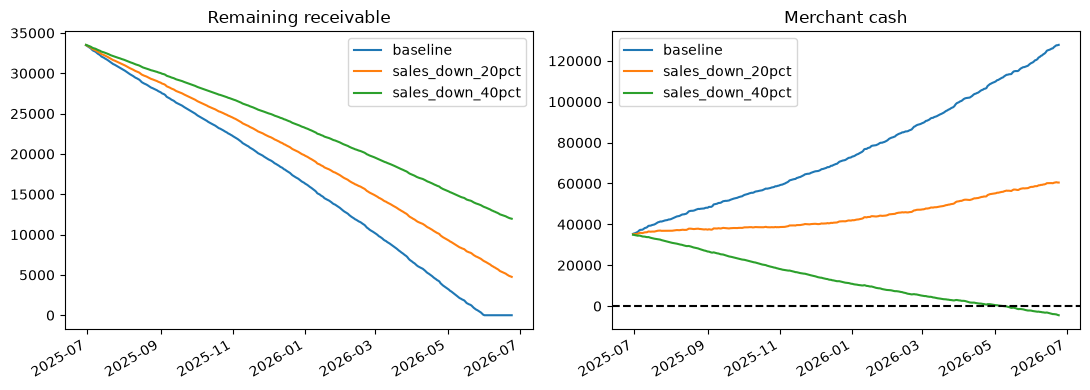

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, path in [("baseline", future), *[(s.name, s.apply(future)) for s in shocks]]:
    schedule = advance.simulate(path, opening_cash=5_000).schedule
    axes[0].plot(schedule["date"], schedule["remaining_balance"], label=name)
    axes[1].plot(schedule["date"], schedule["cash_balance"], label=name)
axes[0].set_title("Remaining receivable")
axes[1].set_title("Merchant cash")
axes[1].axhline(0, color="black", linestyle="--")
for ax in axes:
    ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

For the exact README styling, run
[visual_walkthrough.py](https://github.com/datakim/lendrisk/blob/main/examples/visual_walkthrough.py)
from a cloned checkout.

## 5. Add payment conditions when the agreement requires them


In [6]:
from lendrisk import MinimumPayment, RepaymentMilestone

conditioned = RevenueAdvance(
    principal=30_000,
    factor_rate=1.12,
    holdback_rate=0.10,
    minimum_payment=MinimumPayment(amount=1_500, every_days=30),
    milestones=(RepaymentMilestone(day=180, cumulative_fraction=0.50),),
)
conditioned_result = conditioned.simulate(future, opening_cash=5_000)
print(conditioned_result.summary())

{'principal': 30000.0, 'target_repayment': 33600.0, 'total_paid': 33600.000000000015, 'remaining_balance': 0.0, 'repaid': True, 'payoff_date': Timestamp('2026-06-01 00:00:00'), 'payoff_days': 337, 'horizon_days': 360, 'recovery_ratio': 1.0000000000000004, 'effective_annual_return': 0.27097544468793067, 'return_status': 'calculated', 'minimum_cash_balance': 35363.27947135184, 'negative_cash_days': 0, 'total_minimum_topup': 0.0, 'milestones_observed': 1, 'milestones_breached': 1}


A **floor** adds a top-up at the end of each complete 30-day block if revenue
payments fall short of 1,500. A **milestone** checks cumulative payments on day
180; it reports a shortfall and does not add a payment automatically. Configure
these mechanics from the agreement you are analyzing.

## Understand the limits of the schedule

Scheduled payments are assumed collected, even if cash goes negative. To model
missed collections, defaults, recoveries, or payment priority, you need an
additional model. If operating costs are absent, cash-balance metrics are
unknown. Unobserved payoff and annual return remain `None`.

Check `return_status` to distinguish an unrepaid horizon from an annual return
that is outside the supported numerical range. `out_of_range` leaves the
repayment and liquidity summary intact; it does not imply failed collection.

[Bring your own data](https://github.com/datakim/lendrisk/blob/main/docs/your-data.md) · [Calculation conventions](https://github.com/datakim/lendrisk/blob/main/docs/conventions.md) ·
[Open this tutorial as a notebook](https://colab.research.google.com/github/datakim/lendrisk/blob/main/notebooks/01_revenue_financing.ipynb)
